# EngineWatch: an inspectable remaining-life experiment

## tl;dr

The selected **Gradient boosting** model achieves **14.83 cycles MAE** and **21.48 cycles RMSE** on all **100 official FD001 test-engine endpoints**. MAE is **53.8% lower** than the age-only baseline in this run. The nominal 90% split-conformal intervals contain **97%** of endpoint truths, with a mean width of **101.7 cycles**.

Ridge regression has a lower asymmetric NASA score despite higher MAE and RMSE. The selected model follows the declared validation-MAE objective; it does not dominate every metric. Its 97% coverage is accompanied by a broad interval averaging about 102 cycles, so coverage alone must not be presented as precise forecasting.

This notebook is an executed audit of the shipped experiment. It reads the prediction-level artifact, independently recomputes metrics, checks them against the dashboard summary, and renders figures from the actual predictions. It does not rerun model selection on the test data.

**Scope:** NASA's simulated, single-regime FD001 benchmark. These measurements do not demonstrate accuracy on physical aircraft or certify a maintenance decision.


## Context & Methods

Predict the number of operating cycles remaining before simulated failure using history available at a selected cycle. RUL targets are uncapped: training-engine final cycle minus the current cycle. The complete method and limitations are in [methods.md](../docs/methods.md) and [model-card.md](../docs/model-card.md).

| Population | Role | Engines |
|---|---|---:|
| Whole training engines | Fit | 60 |
| Whole training engines | Validation: select configuration by MAE | 20 |
| Whole training engines | Independent interval calibration | 20 |
| Official truncated test engines | Final endpoint evaluation | 100 |

Seed 42 fixes membership. Validation and calibration use one truncated endpoint per engine, sampled from cycle 30 through `min(250, lifetime - 1)` with seeds 43 and 44. The selected configuration is refit on 80 fit and validation engines. Calibration engines remain independent. Test labels do not choose models or intervals.

There are 71 predictors: operating age and five causal features from each of 14 fixed sensor channels. Sensor features are current reading, trailing 20-cycle mean, standard deviation, slope, and deviation from the first five available readings. An early cycle uses only its available history. No engine ID or final lifetime enters the model.

### Key Assumptions

- Sensor measurements and engineered features in FD001 contain useful degradation information; transfer to other regimes has not been established.
- Whole-engine separation is required because adjacent cycles are correlated.
- The nominal conformal level relies on exchangeability of calibration and test endpoints. Our artificial training truncations may differ from the official test distribution.
- Twenty calibration engines give a coarse interval estimate. Endpoint coverage cannot be promoted to a guarantee for a chosen engine or all its replay cycles.
- Dashboard sensor substitutions are terminal-cycle model sensitivities, not causal attribution or SHAP values; they are separate from the history replay.


### Setup and reproducibility

From the repository root, install the notebook dependencies with `python -m pip install -e ".[notebook]"`. The notebook runs using the included evaluation artifacts and makes no network requests. To regenerate the model and artifacts first, run `python -m enginewatch.train`; this automatically downloads the source archive if it is not cached.

The source is [NASA C-MAPSS FD001](https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data), distributed in the [NASA-attributed Zenodo archive, DOI 10.5281/zenodo.15346912](https://doi.org/10.5281/zenodo.15346912). The checked-in predictions are derived experiment outputs. Source terms and attribution are in [DATA_LICENSE.md](../DATA_LICENSE.md).


In [1]:
from pathlib import Path
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# Works when launched from the repository root or notebooks/ directory.
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "artifacts" / "test_predictions.csv").exists()), None)
assert REPO is not None, "Open this notebook from within the EngineWatch repository."
FIGURES = REPO / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (9, 4.8), "figure.dpi": 120,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 15, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#bbc3cd", "text.color": "#1c293a",
    "axes.labelcolor": "#1c293a", "xtick.color": "#34465d",
    "ytick.color": "#34465d", "savefig.facecolor": "white",
})
BLUE, GOLD, CHARCOAL = "#2468bb", "#bd771e", "#263548"
pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 8)
print(f"Python {platform.python_version()} | pandas {pd.__version__} | NumPy {np.__version__} | Matplotlib {matplotlib.__version__}")


Python 3.12.14 | pandas 3.0.6 | NumPy 2.5.3 | Matplotlib 3.11.2


## Data

### Load the inspectable experiment artifacts

`test_predictions.csv` has one row per official test engine. `results.json` preserves experiment configuration and split membership. `demo.json` is the precomputed dashboard's data source. This notebook computes headline numbers from CSV rows and uses the dashboard summary only for reconciliation.


In [2]:
predictions = pd.read_csv(REPO / "artifacts" / "test_predictions.csv")
results = json.loads((REPO / "artifacts" / "results.json").read_text(encoding="utf-8"))
demo = json.loads((REPO / "artifacts" / "demo.json").read_text(encoding="utf-8"))
summary = demo["summary"]
predictions.loc[:, ["engine_id", "cycle", "true_rul", "predicted_rul", "lower_rul", "upper_rul"]].head(6).round(2)


,engine_id,cycle,true_rul,predicted_rul,lower_rul,upper_rul
0,1,31,112.0,175.99,119.86,232.13
1,2,49,98.0,144.99,88.86,201.13
2,3,126,69.0,50.32,0.00,106.45
3,4,106,82.0,88.41,32.28,144.55
4,5,98,91.0,86.15,30.02,142.29
5,6,105,93.0,105.57,49.43,161.71


### Check the endpoint grain and bounds

The following assertions cover all rows, not a sample: exactly 100 unique engines, complete finite predictions, positive true RUL, nonnegative point estimates and bounds, and point estimates within their displayed intervals. A failed assertion stops the notebook before drawing conclusions.


In [3]:
required_columns = ["engine_id", "cycle", "true_rul", "age_baseline_prediction",
                    "ridge_prediction", "gradient_boosting_prediction",
                    "predicted_rul", "lower_rul", "upper_rul"]
assert set(required_columns).issubset(predictions.columns)
assert len(predictions) == 100
assert predictions.engine_id.nunique() == 100
assert set(predictions.engine_id) == set(range(1, 101))
assert np.isfinite(predictions[required_columns].to_numpy()).all()
assert (predictions.true_rul > 0).all()
assert (predictions.cycle > 0).all()
assert (predictions[["predicted_rul", "lower_rul", "upper_rul"]] >= 0).all().all()
assert (predictions.lower_rul <= predictions.predicted_rul).all()
assert (predictions.predicted_rul <= predictions.upper_rul).all()
print(f"Validated {len(predictions)} endpoint rows from {predictions.engine_id.nunique()} independent test engines.")


Validated 100 endpoint rows from 100 independent test engines.


### Check independent training roles and selection evidence

Whole-engine split membership is retained in the experiment configuration. The same numeric engine IDs in the official train and test files refer to separate trajectories; the disjointness check below applies within the training-file roles.


In [4]:
split_ids = results["split_ids"]
fit_engines = set(split_ids["fit_engine_ids"])
validation_engines = set(split_ids["validation_engine_ids"])
calibration_engines = set(split_ids["calibration_engine_ids"])
assert len(fit_engines) == 60 and len(validation_engines) == 20 and len(calibration_engines) == 20
assert not (fit_engines & validation_engines or fit_engines & calibration_engines or validation_engines & calibration_engines)
assert fit_engines | validation_engines | calibration_engines == set(range(1, 101))
assert results["feature_count"] == 71 and results["window"] == 20
selection_evidence = pd.DataFrame([
    {"Model": row["model"], "Validation MAE (cycles)": row["validation_mae"],
     "Selected by validation MAE": row["model"] == summary["selected_model"]}
    for row in results["metrics"]
])
assert selection_evidence.loc[selection_evidence["Validation MAE (cycles)"].idxmin(), "Model"] == summary["selected_model"]
selection_evidence.round(2)


,Model,Validation MAE (cycles),Selected by validation MAE
0,Age baseline,29.14,False
1,Ridge regression,27.34,False
2,Gradient boosting,27.07,True


## Results

### Recompute the three-model leaderboard

For error `prediction - truth`, MAE averages its absolute value and RMSE is the square root of mean squared error. The asymmetric NASA/PHM score sums `exp(-error / 13) - 1` for underpredictions and `exp(error / 10) - 1` otherwise. **Lower is better for all three metrics.** The score is dimensionless and gives a steeper penalty to overestimated lifetime.


In [5]:
def endpoint_metrics(estimate, truth):
    error = np.asarray(estimate) - np.asarray(truth)
    penalty = np.where(error < 0, np.expm1(-error / 13), np.expm1(error / 10))
    return {"MAE (cycles)": float(np.mean(np.abs(error))),
            "RMSE (cycles)": float(np.sqrt(np.mean(error ** 2))),
            "NASA score": float(np.sum(penalty))}

model_columns = {
    "Age baseline": "age_baseline_prediction",
    "Ridge regression": "ridge_prediction",
    "Gradient boosting": "gradient_boosting_prediction",
}
leaderboard = pd.DataFrame([
    {"Model": name, **endpoint_metrics(predictions[column], predictions.true_rul)}
    for name, column in model_columns.items()
]).set_index("Model")
selected_metrics = endpoint_metrics(predictions.predicted_rul, predictions.true_rul)
for published in summary["metrics"] + results["metrics"]:
    computed = leaderboard.loc[published["model"]]
    for source_key, label in [("mae", "MAE (cycles)"), ("rmse", "RMSE (cycles)"), ("nasa_score", "NASA score")]:
        assert np.isclose(computed[label], published[source_key], rtol=1e-5, atol=0.01), (published["model"], label)
leaderboard.round(2)


,MAE (cycles),RMSE (cycles),NASA score
Model,,,
Age baseline,32.11,40.23,25562.38
Ridge regression,22.20,26.89,2151.19
Gradient boosting,14.83,21.48,2439.53


### Compare test-endpoint MAE

This comparison holds the endpoint population and target definition fixed. All three models use the same 100 engines; selection used validation engines before this final evaluation.


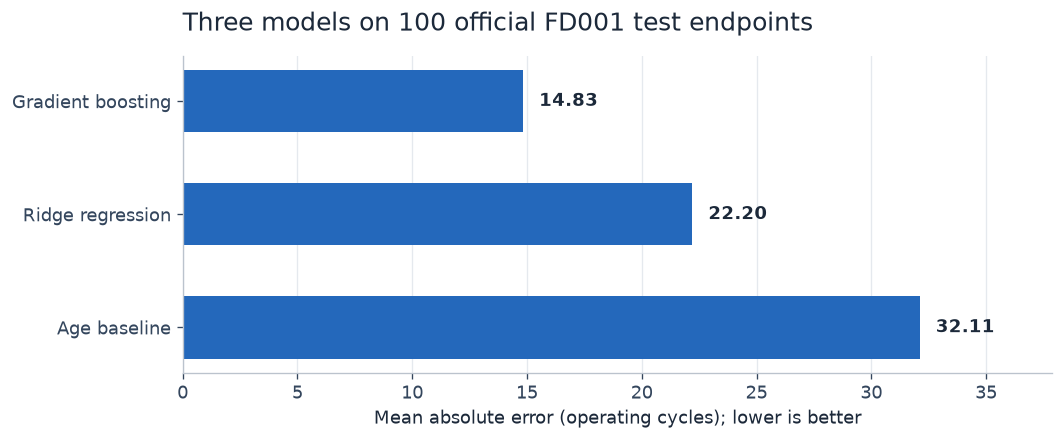

In [6]:
ordered = leaderboard.sort_values("MAE (cycles)", ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(ordered.index, ordered["MAE (cycles)"], color=BLUE, height=0.55)
ax.set_xlim(0, ordered["MAE (cycles)"].max() * 1.18)
ax.set_xlabel("Mean absolute error (operating cycles); lower is better")
ax.set_title("Three models on 100 official FD001 test endpoints", loc="left", pad=15)
ax.grid(axis="x", color="#e5e9ee", linewidth=0.8)
ax.set_axisbelow(True)
for bar, value in zip(bars, ordered["MAE (cycles)"]):
    ax.text(value + 0.7, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center", weight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "model-comparison.png", dpi=160, bbox_inches="tight")
plt.show()


In [7]:
age_mae = leaderboard.loc["Age baseline", "MAE (cycles)"]
reduction = 100 * (1 - selected_metrics["MAE (cycles)"] / age_mae)
print(f"Selected model: {summary['selected_model']}")
print(f"Test MAE is {reduction:.1f}% lower than the age-only baseline in this run.")
print("A single split of FD001 does not establish robustness on other benchmark variants.")


Selected model: Gradient boosting
Test MAE is 53.8% lower than the age-only baseline in this run.
A single split of FD001 does not establish robustness on other benchmark variants.


Ridge regression's test NASA score (2,151.19) is lower than gradient boosting's (2,439.53), even though gradient boosting has lower MAE and RMSE. The nonlinear model is selected for the prespecified validation-MAE objective. A decision driven by asymmetrically costly overestimates could motivate a different objective in a new, properly validated experiment.


### Inspect every endpoint prediction

Each marker is one engine's final available test cycle. The dashed diagonal is a perfect prediction, not a fitted trend line. Points above it overestimate lifetime; points below underestimate it. Both axes use cycles and share the same scale.


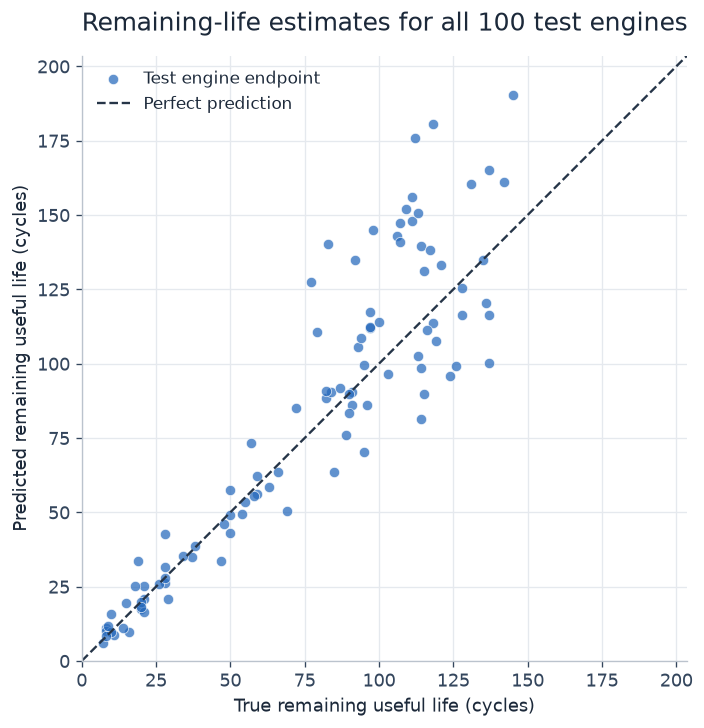

In [8]:
limit = float(max(predictions.true_rul.max(), predictions.predicted_rul.max()) * 1.07)
fig, ax = plt.subplots(figsize=(7, 6.2))
ax.scatter(predictions.true_rul, predictions.predicted_rul, s=38, color=BLUE,
           alpha=0.72, edgecolors="white", linewidths=0.5, label="Test engine endpoint")
ax.plot([0, limit], [0, limit], linestyle="--", color=CHARCOAL, linewidth=1.4, label="Perfect prediction")
ax.set(xlim=(0, limit), ylim=(0, limit), xlabel="True remaining useful life (cycles)",
       ylabel="Predicted remaining useful life (cycles)")
ax.set_aspect("equal", adjustable="box")
ax.set_title("Remaining-life estimates for all 100 test engines", loc="left", pad=15)
ax.grid(color="#e5e9ee", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "prediction-scatter.png", dpi=160, bbox_inches="tight")
plt.show()


### Examine errors across remaining lifetime

Average error can hide different behavior at short and long remaining lifetimes. Positive residuals mean overestimated life. The second panel shows the same 100 errors as a distribution; bins are contiguous numerical intervals.


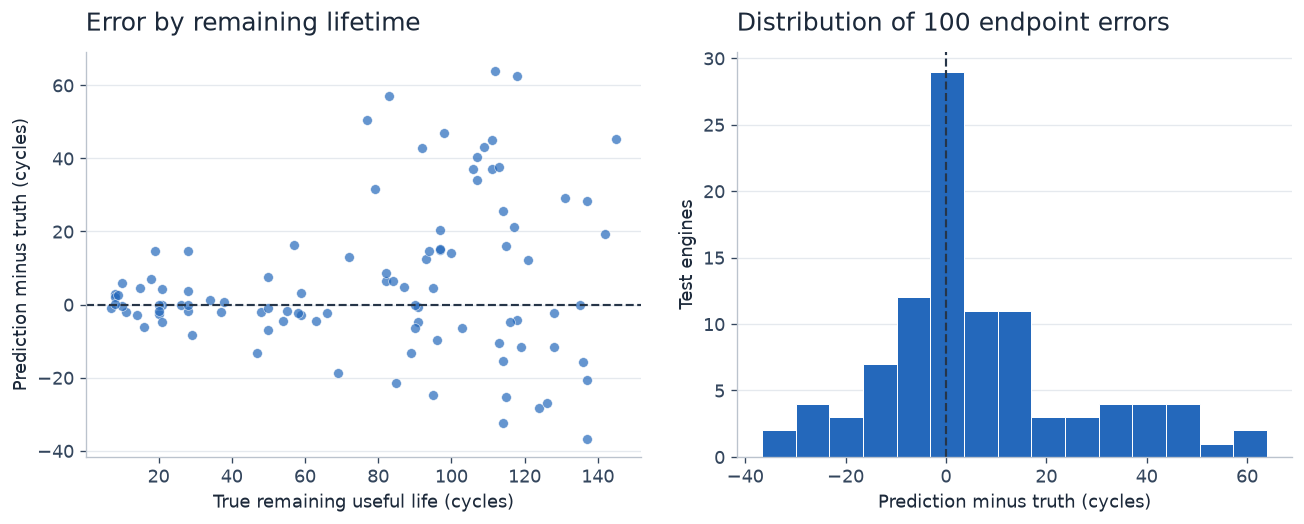

In [9]:
residual = predictions.predicted_rul - predictions.true_rul
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(predictions.true_rul, residual, s=34, color=BLUE, alpha=0.7,
                edgecolors="white", linewidths=0.4)
axes[0].axhline(0, color=CHARCOAL, linewidth=1.3, linestyle="--")
axes[0].set(xlabel="True remaining useful life (cycles)", ylabel="Prediction minus truth (cycles)")
axes[0].set_title("Error by remaining lifetime", loc="left", pad=13)
axes[1].hist(residual, bins=15, color=BLUE, edgecolor="white", linewidth=0.6)
axes[1].axvline(0, color=CHARCOAL, linewidth=1.3, linestyle="--")
axes[1].set(xlabel="Prediction minus truth (cycles)", ylabel="Test engines")
axes[1].set_title("Distribution of 100 endpoint errors", loc="left", pad=13)
for ax in axes:
    ax.grid(axis="y", color="#e5e9ee", linewidth=0.8)
    ax.set_axisbelow(True)
fig.tight_layout(w_pad=2)
fig.savefig(FIGURES / "residual-diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()


In [10]:
diagnostics = pd.DataFrame({
    "Measure": ["Mean signed error (cycles)", "Overestimated endpoints", "Underestimated endpoints", "Worst absolute error (cycles)"],
    "Value": [residual.mean(), (residual > 0).sum(), (residual < 0).sum(), residual.abs().max()],
})
diagnostics.round(2)


,Measure,Value
0,Mean signed error (cycles),6.25
1,Overestimated endpoints,50.00
2,Underestimated endpoints,50.00
3,Worst absolute error (cycles),63.99


### Check empirical prediction-interval coverage

The selected model's nominal 90% split-conformal interval is calibrated from absolute residuals on 20 independent engines. The 19th ordered residual supplies the half-width, and lower bounds are clipped at zero. Coverage below is recalculated using **all 100 official test endpoints**. Its denominator is not all replay cycles.


In [11]:
covered = (predictions.true_rul >= predictions.lower_rul) & (predictions.true_rul <= predictions.upper_rul)
calibration = pd.read_csv(REPO / "artifacts" / "calibration_predictions.csv")
assert set(calibration.engine_id) == calibration_engines and len(calibration) == 20
independent_residuals = np.abs(calibration.predicted_rul - calibration.true_rul)
assert np.allclose(independent_residuals, calibration.absolute_error)
rank = int(np.ceil((len(calibration) + 1) * summary["interval"]["nominal_coverage"]))
radius = float(np.sort(independent_residuals)[rank - 1])
assert rank == 19 and np.isclose(radius, summary["interval"]["radius"])
assert np.allclose(predictions.lower_rul, np.maximum(0, predictions.predicted_rul - radius))
assert np.allclose(predictions.upper_rul, predictions.predicted_rul + radius)
interval_coverage = float(covered.mean())
mean_width = float((predictions.upper_rul - predictions.lower_rul).mean())
assert np.isclose(interval_coverage, summary["interval"]["test_coverage"], atol=1e-8)
assert np.isclose(mean_width, summary["interval"]["mean_width"], rtol=1e-5, atol=0.01)
interval_summary = pd.DataFrame({
    "Measure": ["Nominal coverage", "Observed endpoint coverage", "Covered test engines", "Mean interval width (cycles)", "Calibration engines"],
    "Value": ["90%", f"{interval_coverage:.0%}", f"{int(covered.sum())} / 100", f"{mean_width:.2f}", "20"],
})
interval_summary


,Measure,Value
0,Nominal coverage,90%
1,Observed endpoint coverage,97%
2,Covered test engines,97 / 100
3,Mean interval width (cycles),101.69
4,Calibration engines,20


### See estimates, truths, and bounds together

To preserve readability, this view displays every fourth engine after sorting by true RUL (25 engines). The coverage calculation above still uses the entire 100-engine evaluation set. The sample is deterministic and selected by position, not by prediction quality. Intervals are prediction intervals for RUL, not confidence intervals for average error.


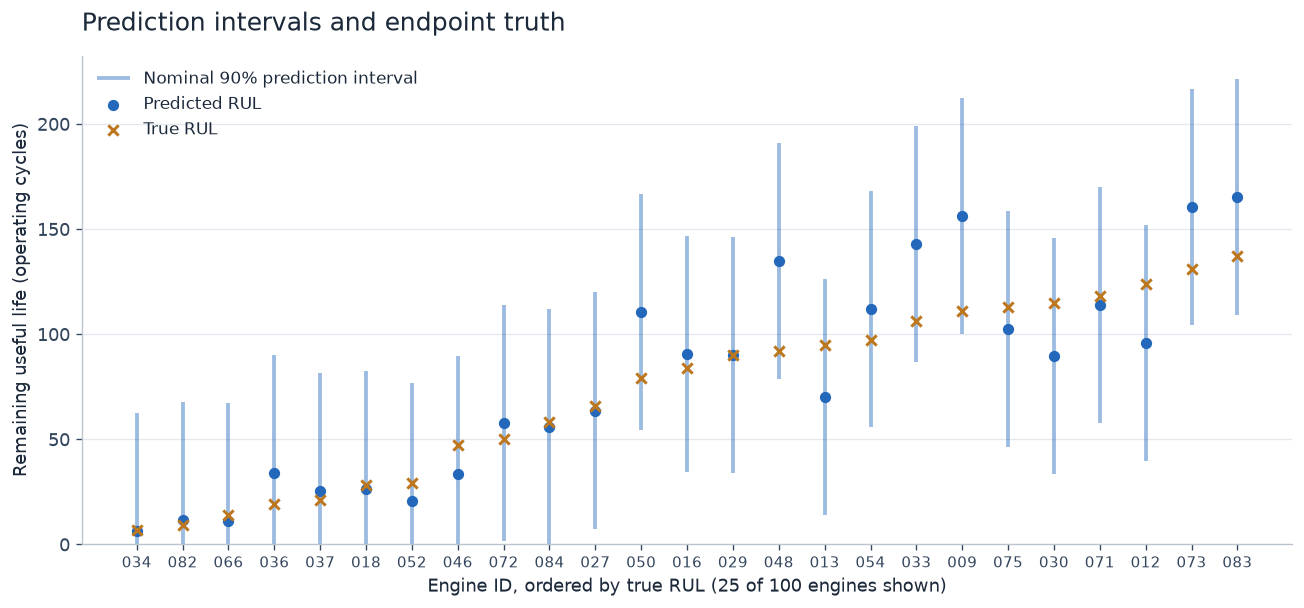

In [12]:
sample = predictions.sort_values(["true_rul", "engine_id"]).iloc[::4].reset_index(drop=True)
positions = np.arange(len(sample))
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.vlines(positions, sample.lower_rul, sample.upper_rul, color=BLUE, alpha=0.45, linewidth=2.3,
          label="Nominal 90% prediction interval")
ax.scatter(positions, sample.predicted_rul, s=33, color=BLUE, zorder=3, label="Predicted RUL")
ax.scatter(positions, sample.true_rul, marker="x", s=38, color=GOLD, linewidths=1.8,
           zorder=4, label="True RUL")
ax.set_xticks(positions, [f"{int(x):03d}" for x in sample.engine_id], fontsize=9)
ax.set(xlabel="Engine ID, ordered by true RUL (25 of 100 engines shown)",
       ylabel="Remaining useful life (operating cycles)", ylim=(0, None))
ax.set_title("Prediction intervals and endpoint truth", loc="left", pad=15)
ax.grid(axis="y", color="#e5e9ee", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(loc="upper left", frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "prediction-intervals.png", dpi=160, bbox_inches="tight")
plt.show()


The displayed band width is a single calibrated residual quantile with a nonnegative lower-bound adjustment. It is deliberately transparent, and it does not establish conditional coverage for each lifetime range. Calibration endpoints were sampled from training trajectories, so a shift relative to the official test truncations can affect empirical coverage.


## Takeaways

- The selected model's measured MAE is **14.83 cycles**, compared with **32.11 cycles** for the age-only baseline. This run provides evidence that the engineered sensor histories improve endpoint predictions on FD001.
- The nominal 90% intervals cover **97%** of the 100 official endpoints and average **101.7 cycles** in width. Coverage and width should be considered together; a broad interval can cover more truth without providing a precise estimate.
- Ridge achieves the lower asymmetric NASA score, while the selected nonlinear model achieves lower MAE and RMSE. The preferred model depends on the declared objective.
- All endpoint-level metrics and coverage reconcile with the shipped dashboard. The plots show the full prediction population where density permits and explicitly label the 25-engine interval display.
- The next evidence to seek is performance across seeds, FD002/FD004 operating regimes, and calibration sampling rules. Greater model complexity alone would not answer those generalization questions.

**Validation:** this notebook is saved with outputs after a top-to-bottom execution. Raw inputs, exact code, and experiment configuration remain traceable through the repository. The notebook is an artifact audit; rerunning the training command is required to reproduce model fitting itself.
